In [26]:
from rectpack import newPacker, float2dec
from rectpack import PackingMode
from rectpack.guillotine import GuillotineBlsfSas


rectangles = [
    (60.3, 40.3),       (60.3, 40.3),       (60.3, 40.3), 
    (20.4, 35.2),       (20.4, 35.2),       (20.4, 35.2), 
    (123.4, 142.5),     (123.4, 142.5),     (123.4, 142.5), 
    (200, 100),         (100, 200),         (100, 100),
    (20, 20),           (400, 400),         (20, 21),
    (20, 21),           (20, 21),           (30, 35),
    (30, 35),           (30, 35),
    ]
bins = [(300.24, 450.36), (1e10, 1e10)]
rectangles, bins = list(map(lambda x:[(float2dec(r[0], 3), float2dec(r[1], 3)) 
                                      for r in x], 
                            [rectangles, bins]))


packer = newPacker(
    mode=PackingMode.Online,
    rotation=False
    )

In [27]:
packer.add_bin(*bins[0])

for rid, rect in enumerate(rectangles):
    packer.add_rect(*rect, rid=rid)
    print(rid, packer.validate_packing())


0 None
1 None
2 None
3 None
4 None
5 None
6 None
7 None
8 None
9 None
10 None
11 None
12 None
13 None
14 None
15 None
16 None
17 None
18 None
19 None


In [28]:
# if .rect_list() returns the same list of rects, 
# then packing results in failure.

In [29]:
packer.rect_list()

[(0, 0, 0, Decimal('60.300'), Decimal('40.300'), 0),
 (0, Decimal('60.300'), 0, Decimal('60.300'), Decimal('40.300'), 1),
 (0, Decimal('120.600'), 0, Decimal('60.300'), Decimal('40.300'), 2),
 (0, Decimal('180.900'), 0, Decimal('20.400'), Decimal('35.201'), 3),
 (0, Decimal('201.300'), 0, Decimal('20.400'), Decimal('35.201'), 4),
 (0, Decimal('221.700'), 0, Decimal('20.400'), Decimal('35.201'), 5),
 (0, 0, Decimal('40.300'), Decimal('123.401'), Decimal('142.500'), 6),
 (0,
  Decimal('123.401'),
  Decimal('40.300'),
  Decimal('123.401'),
  Decimal('142.500'),
  7),
 (0, 0, Decimal('182.800'), Decimal('123.401'), Decimal('142.500'), 8),
 (0, 0, Decimal('325.300'), Decimal('200.000'), Decimal('100.000'), 9),
 (0,
  Decimal('200.000'),
  Decimal('182.800'),
  Decimal('100.000'),
  Decimal('200.000'),
  10),
 (0, 0, Decimal('425.300'), Decimal('20.000'), Decimal('20.000'), 12),
 (0,
  Decimal('20.000'),
  Decimal('425.300'),
  Decimal('20.000'),
  Decimal('21.000'),
  14),
 (0,
  Decimal('4

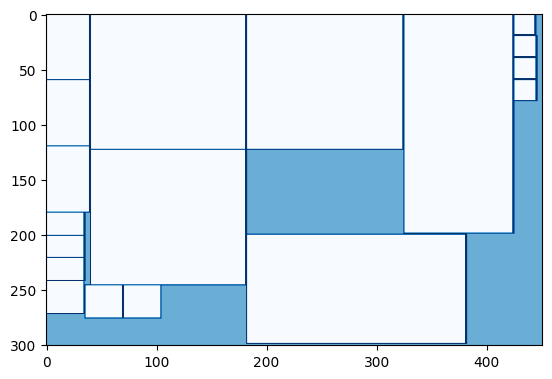

In [30]:
# discretization to 224x224 grid

import torch
import matplotlib.pyplot as plt
from math import floor, ceil

grid = torch.zeros(size=tuple(map(ceil, 
                                  bins[0])))

for (c, x, y, w, h, id) in packer.rect_list():
    grid[floor(x):ceil(x+w), floor(y):ceil(y+h)] = 1
    grid[floor(x+1):ceil(x+w-1), floor(y+1):floor(y+h-1)] = -1

plt.imshow(grid, cmap="Blues")

In [42]:
import math

math.floor(1.0), math.ceil(1.0)

(1, 1)